In [3]:
import warnings
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ПУТИ К ДАННЫМ
PATH_CHECKPOINT = "/Users/sepilovstepansergeevic/Desktop/Code/neftecode/hack/data/STransformer_078316.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# КОНСТАНТЫ
TARGET_COLS_INTERNAL = ["target_visc", "target_oxid"]
TARGET_COLS_SUBMISSION = [
    "Delta Kin. Viscosity KV100 - relative | - Daimler Oxidation Test (DOT), %",
    "Oxidation EOT | DIN 51453 Daimler Oxidation Test (DOT), A/cm"
]
DOSE_COL = "mass_norm"
D_MODEL = 32  
N_HEADS = 4
N_LAYERS = 2  
D_FF = 64
DROPOUT = 0.25
N_SEEDS = 3
BATCH_SIZE = 16

/Users/sepilovstepansergeevic/Desktop/Code/neftecode/hack/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def build_component_vocab(train_df, test_df):
    all_comps = sorted(set(train_df["component"].unique()) | set(test_df["component"].unique()))
    comp_to_idx = {c: i + 1 for i, c in enumerate(all_comps)}
    return comp_to_idx

def get_feature_columns(df):
    exclude = ['scenario_id', 'component', 'mass_norm', 'target_visc', 'target_oxid', 'target_visc_log', 'hidden_pct',
               'temp', 'time', 'biofuel', 'catalyst']
    return [c for c in df.columns if c not in exclude]

def build_scenarios(mixture_df, comp_to_idx, feature_cols, is_train=True):
    scenarios = []
    for sid, grp in mixture_df.groupby("scenario_id"):
        comp_features, comp_ids, raw_doses = [], [], []
        for _, row in grp.iterrows():
            comp_name = row["component"]
            dose = row[DOSE_COL]
            raw_doses.append(dose)
            comp_ids.append(comp_to_idx.get(comp_name, 0))
            feats = row[feature_cols].values.astype(np.float32)
            full_vector = np.concatenate([[dose], feats])
            comp_features.append(full_vector)

        first_row = grp.iloc[0]
        global_feats = np.array([first_row['temp'], first_row['time'], first_row['biofuel'], first_row['catalyst']], dtype=np.float32)

        scenario = {
            "components": np.stack(comp_features),
            "comp_ids": np.array(comp_ids, dtype=np.int64),
            "global_feats": global_feats, 
            "raw_doses": np.array(raw_doses, dtype=np.float32),
            "scenario_id": sid
        }
        if is_train:
            targets_raw = np.array([first_row[TARGET_COLS_INTERNAL[0]], first_row[TARGET_COLS_INTERNAL[1]]], dtype=np.float32)
            scenario["targets"] = targets_raw
        scenarios.append(scenario)
    return scenarios

In [5]:
class DOTDataset(Dataset):
    def __init__(self, scenarios, feat_scaler=None, global_scaler=None, target_scaler=None, fit_scalers=False):
        self.scenarios = scenarios
        self.has_targets = "targets" in scenarios[0]

        if fit_scalers:
            all_feats = np.concatenate([s["components"] for s in scenarios], axis=0)
            all_globals = np.stack([s["global_feats"] for s in scenarios])
            self.feat_scaler = StandardScaler().fit(all_feats)
            self.global_scaler = StandardScaler().fit(all_globals)
            if self.has_targets:
                all_targets = np.stack([s["targets"] for s in scenarios])
                self.target_scaler = StandardScaler().fit(all_targets)
        else:
            self.feat_scaler, self.global_scaler, self.target_scaler = feat_scaler, global_scaler, target_scaler

        for s in self.scenarios:
            s["components_scaled"] = self.feat_scaler.transform(s["components"]).astype(np.float32)
            if self.has_targets and self.target_scaler is not None:
                s["targets_scaled"] = self.target_scaler.transform(s["targets"].reshape(1, -1)).flatten().astype(np.float32)

    def __len__(self):
        return len(self.scenarios)

    def __getitem__(self, idx):
        s = self.scenarios[idx]
        comps = s["components_scaled"].copy()
        comp_ids = s["comp_ids"].copy()
        gf = s["global_feats"].copy()
        gf_scaled = self.global_scaler.transform(gf.reshape(1, -1)).flatten().astype(np.float32)
        
        if self.has_targets:
            return torch.tensor(comps), torch.tensor(comp_ids), torch.tensor(gf_scaled), torch.tensor(s["targets_scaled"])
        return torch.tensor(comps), torch.tensor(comp_ids), torch.tensor(gf_scaled)

def collate_fn(batch):
    has_targets = len(batch[0]) == 4
    components, comp_ids = [b[0] for b in batch], [b[1] for b in batch]
    global_feats = torch.stack([b[2] for b in batch])
    
    max_len = max(c.shape[0] for c in components)
    padded = torch.zeros(len(components), max_len, components[0].shape[1])
    padded_ids = torch.zeros(len(components), max_len, dtype=torch.long)
    mask = torch.zeros(len(components), max_len, dtype=torch.bool)
    
    for i, (c, cid) in enumerate(zip(components, comp_ids)):
        n = c.shape[0]
        padded[i, :n], padded_ids[i, :n], mask[i, :n] = c, cid, True

    if has_targets:
        targets = torch.stack([b[3] for b in batch])
        return padded, padded_ids, global_feats, mask, targets
    return padded, padded_ids, global_feats, mask

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_k, self.n_heads = d_model // n_heads, n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        B, n_q, _ = Q.shape
        _, n_kv, _ = K.shape
        q = self.W_q(Q).view(B, n_q, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_k(K).view(B, n_kv, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_v(V).view(B, n_kv, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None: scores = scores.masked_fill(~mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        attn_weights = self.dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(attn_weights, v).transpose(1, 2).contiguous().view(B, n_q, -1)
        return self.W_o(out), attn_weights

class SetAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model), nn.Dropout(dropout))
        self.norm1, self.norm2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)

    def forward(self, X, mask=None):
        attn_out, _ = self.mha(X, X, X, mask)
        X = self.norm1(X + attn_out)
        return self.norm2(X + self.ffn(X)), None

class PoolingByMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_seeds, dropout=0.1):
        super().__init__()
        self.seeds = nn.Parameter(torch.randn(1, n_seeds, d_model) * 0.01)
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, Z, mask=None):
        out, _ = self.mha(self.seeds.expand(Z.shape[0], -1, -1), Z, Z, mask)
        return self.norm(self.seeds.expand(Z.shape[0], -1, -1) + out), None

class SetTransformerDOT(nn.Module):
    def __init__(self, feat_dim, n_components, d_model=32, n_heads=4, n_layers=2, d_ff=64, n_seeds=3, dropout=0.25, comp_embed_dim=8):
        super().__init__()
        self.comp_embedding = nn.Embedding(n_components + 1, comp_embed_dim, padding_idx=0)
        self.input_proj = nn.Sequential(nn.Linear(feat_dim + comp_embed_dim, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(dropout))
        self.sab_layers = nn.ModuleList([SetAttentionBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.pma = PoolingByMultiHeadAttention(d_model, n_heads, n_seeds, dropout)
        
        head_in_dim = (d_model * n_seeds) + 4
        self.head_visc = nn.Sequential(nn.Linear(head_in_dim, d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, 1))
        self.head_oxid = nn.Sequential(nn.Linear(head_in_dim, d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x, comp_ids, global_feats, mask=None):
        h = self.input_proj(torch.cat([x, self.comp_embedding(comp_ids)], dim=-1))
        if mask is not None: h = h * mask.unsqueeze(-1).float()
        for sab in self.sab_layers:
            h, _ = sab(h, mask)
            if mask is not None: h = h * mask.unsqueeze(-1).float()
        pooled, _ = self.pma(h, mask)
        pooled_flat = pooled.view(pooled.shape[0], -1)
        combined_repr = torch.cat([pooled_flat, global_feats], dim=-1)
        return torch.cat([self.head_visc(combined_repr), self.head_oxid(combined_repr)], dim=-1), None

In [7]:
# Загружаем всё содержимое сразу
checkpoint = torch.load(PATH_CHECKPOINT, map_location=DEVICE, weights_only=False)

# Извлекаем словари и параметры
comp_to_idx = checkpoint['comp_to_idx']
feature_cols = checkpoint['feature_cols']
model_config = checkpoint['model_config']

# Извлекаем предобученные скалеры
f_sc = checkpoint['feat_scaler']
g_sc = checkpoint['global_scaler']
t_sc = checkpoint['target_scaler']

print(f"Чекпоинт загружен. Найдено признаков: {len(feature_cols)}")

Чекпоинт загружен. Найдено признаков: 72


In [8]:
# Создаем модель, используя конфиг из чекпоинта
model = SetTransformerDOT(
    feat_dim=model_config['feat_dim'],
    n_components=model_config['n_components'],
    d_model=model_config['d_model'],
    n_heads=model_config['n_heads'],
    n_layers=model_config['n_layers'],
    d_ff=model_config['d_ff'],
    n_seeds=model_config['n_seeds'],
    dropout=model_config['dropout']
).to(DEVICE)

# Загружаем веса
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Архитектура модели воссоздана, веса загружены.")

Архитектура модели воссоздана, веса загружены.


In [9]:
test_df = pd.read_csv("/Users/sepilovstepansergeevic/Desktop/Code/neftecode/hack/data/val_clean_50_full.csv").fillna(0)
test_scenarios = build_scenarios(test_df, checkpoint['comp_to_idx'], feature_cols, is_train=False)

In [10]:
def predict_for_shap(X_flattened):
    """
    X_flattened: массив размера [Samples, N_components * Feat_dim]
    """
    model.eval()
    # Берем базовый сценарий (например, первый из теста)
    s = test_scenarios[0] 
    n_comps = s["components"].shape[0]
    feat_dim = s["components"].shape[1]
    
    # Восстанавливаем структуру из плоского массива SHAP
    # Для простоты объясним только влияние признаков компонентов
    X_reshaped = X_flattened.reshape(-1, n_comps, feat_dim)
    
    preds_list = []
    with torch.no_grad():
        for i in range(X_reshaped.shape[0]):
            comps_tensor = torch.tensor(X_reshaped[i:i+1]).float()
            ids_tensor = torch.tensor(s["comp_ids"]).unsqueeze(0)
            # Скалируем глобальные признаки
            gf_scaled = torch.tensor(g_sc.transform(s["global_feats"].reshape(1, -1))).float()
            mask = torch.ones((1, n_comps), dtype=torch.bool)
            
            output, _ = model(comps_tensor, ids_tensor, gf_scaled, mask)
            # Де-скалируем таргет (выбираем target_visc - индекс 0)
            pred_orig = t_sc.inverse_transform(output.cpu().numpy())
            preds_list.append(pred_orig[0, 0]) # Предсказываем только вязкость
            
    return np.array(preds_list)

In [11]:
feature_cols = checkpoint['feature_cols']
all_feature_names = ["dose"] + feature_cols # Имена признаков для графика

100%|██████████| 1/1 [00:00<00:00,  1.32it/s]


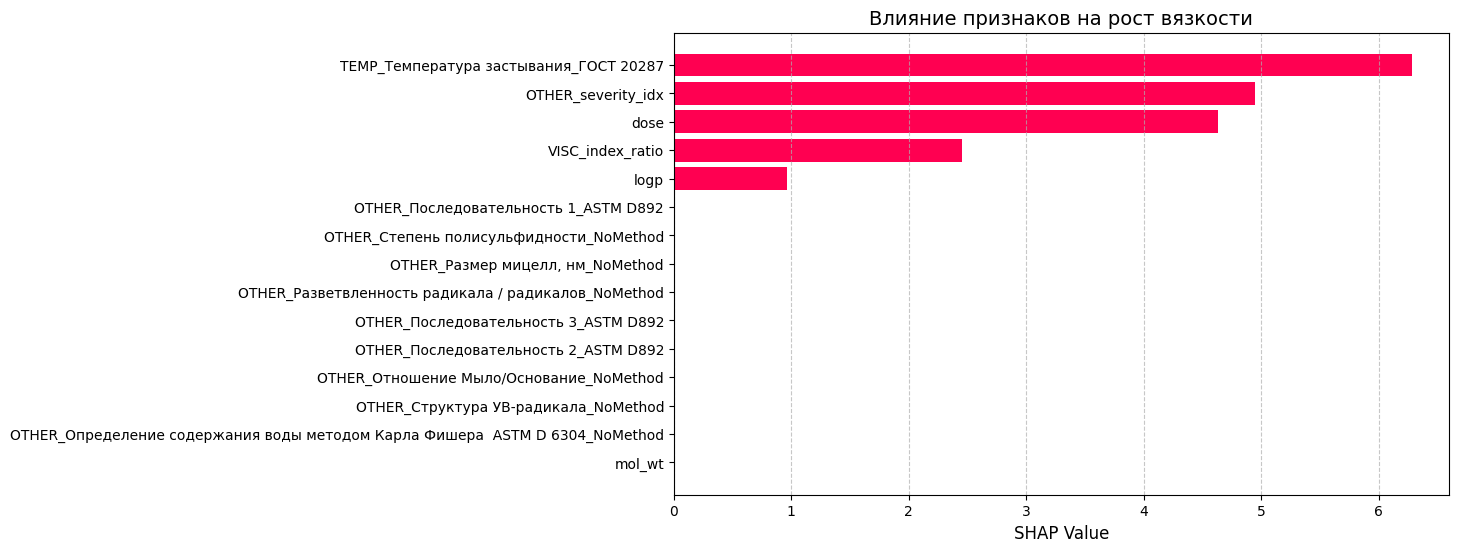

In [12]:
import shap
import matplotlib.pyplot as plt

# 4. ЗАПУСК SHAP
# Выберем фон (background) - усредненные значения
# И данные для объяснения (наш сценарий)
s_to_explain = test_scenarios[0]
n_c = s_to_explain["components"].shape[0]
f_d = s_to_explain["components"].shape[1]

# Создаем "плоские" данные для SHAP
data_to_explain = s_to_explain["components"].reshape(1, -1) 
background_data = np.zeros((10, n_c * f_d)) # Упрощенный фон

explainer = shap.KernelExplainer(predict_for_shap, background_data)
shap_values = explainer.shap_values(data_to_explain, nsamples=100)

# 5. ВИЗУАЛИЗАЦИЯ (ТО САМОЕ ДЛЯ ПРЕЗЕНТАЦИИ)
# Превращаем плоские shap_values обратно в читаемый вид
# Мы объединим вклады по всем компонентам, чтобы увидеть общую важность фичей

# Суммируем важность признаков по всем компонентам в рецептуре
shap_sum = shap_values.reshape(n_c, f_d).sum(axis=0)

# Создаем красивый горизонтальный Bar Chart
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'SHAP Importance': shap_sum
}).sort_values(by='SHAP Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#ff0051' if x > 0 else '#008bfb' for x in importance_df['SHAP Importance']]
plt.barh(importance_df['Feature'], importance_df['SHAP Importance'], color=colors)
plt.title("Влияние признаков на рост вязкости", fontsize=14)
plt.xlabel("SHAP Value", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

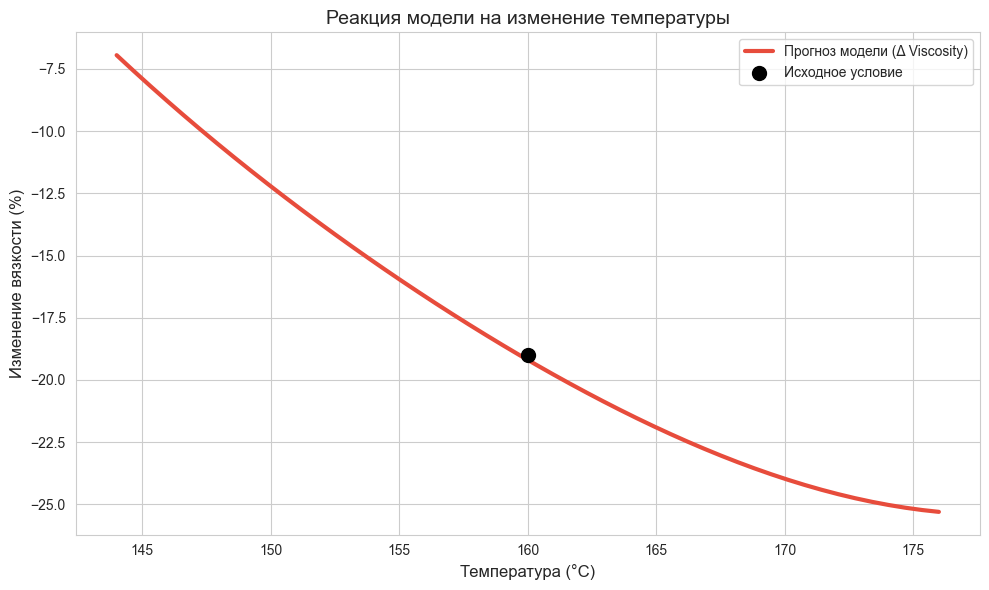

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# 1. ПОДГОТОВКА ДАННЫХ
# Берем первый сценарий из списка сырых тестовых сценариев
scenario_idx = 0
base_scenario = test_scenarios[scenario_idx]

# Убедимся, что модель на нужном устройстве
model.to(DEVICE)
model.eval()

# Заранее масштабируем компоненты этого сценария, используя скалер из чекпоинта
# (build_scenarios выдает сырые данные в ключе 'components')
comps_raw = base_scenario['components']
comps_scaled = f_sc.transform(comps_raw).astype(np.float32)

# Параметр для варьирования: Температура (индекс 0 в global_feats)
param_name = "Температура (°C)"
original_temp = base_scenario['global_feats'][0] 

# Генерируем диапазон температур: +/- 10% от исходной
variations = np.linspace(original_temp * 0.9, original_temp * 1.1, 50)

# 2. ЦИКЛ ПРЕДСКАЗАНИЙ
preds = []

with torch.no_grad():
    # Подготавливаем тензоры, которые не меняются
    comps_tensor = torch.tensor(comps_scaled).unsqueeze(0).to(DEVICE) # [1, N, D]
    ids_tensor = torch.tensor(base_scenario['comp_ids']).unsqueeze(0).to(DEVICE) # [1, N]
    mask = torch.ones((1, ids_tensor.shape[1]), dtype=torch.bool).to(DEVICE)

    for val in variations:
        # Создаем копию глобальных признаков и меняем только температуру
        gf_current = base_scenario['global_feats'].copy()
        gf_current[0] = val 
        
        # Масштабируем глобальные признаки скалером g_sc из чекпоинта
        gf_scaled = torch.tensor(g_sc.transform(gf_current.reshape(1, -1))).float().to(DEVICE)
        
        # Предсказание модели
        output, _ = model(comps_tensor, ids_tensor, gf_scaled, mask)
        
        # Обратное масштабирование таргета (вязкость - индекс 0)
        # t_sc.inverse_transform ожидает [Samples, Targets]
        pred_orig = t_sc.inverse_transform(output.cpu().numpy())[0, 0]
        preds.append(pred_orig)

# 3. ВИЗУАЛИЗАЦИЯ
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Рисуем линию предсказаний
plt.plot(variations, preds, color='#E74C3C', lw=3, label='Прогноз модели (Δ Viscosity)')

# Отмечаем исходную точку, которая была в данных
# (Находим индекс значения, максимально близкого к оригиналу)
idx_orig = (np.abs(variations - original_temp)).argmin()
plt.scatter([original_temp], [preds[idx_orig]], color='black', s=100, zorder=5, label='Исходное условие')

# Оформление графика
plt.title('Реакция модели на изменение температуры', fontsize=14)
plt.xlabel(f'{param_name}', fontsize=12)
plt.ylabel('Изменение вязкости (%)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

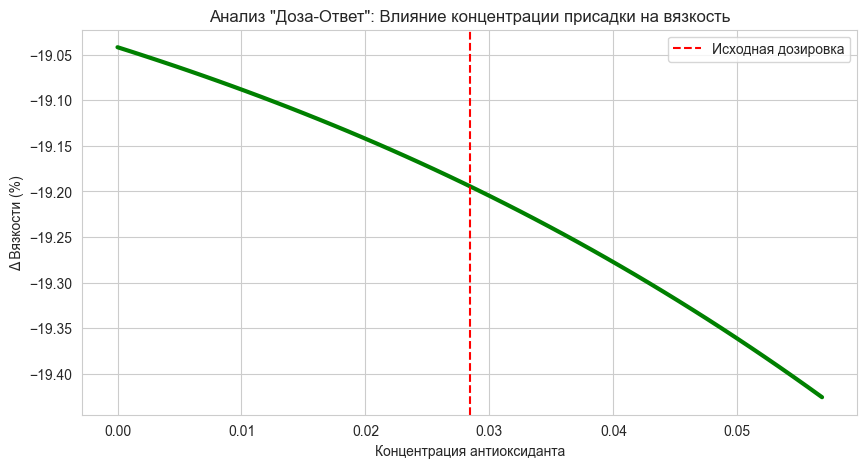

In [18]:
# Выбираем компонент для теста (например, первый в списке)
comp_idx_to_vary = 0 
original_mass = base_scenario['components'][comp_idx_to_vary, 0] # mass_norm это первый столбец

# Генерируем диапазон дозировок (от 0% до 200% от исходной)
mass_variations = np.linspace(0, original_mass * 2.0, 50)

preds_mass = []
with torch.no_grad():
    for m_val in mass_variations:
        # Клонируем исходные компоненты
        comps_variant = comps_scaled.copy()
        
        # ВАЖНО: Нам нужно поменять значение mass_norm ДО масштабирования 
        # или имитировать изменение уже в масштабированном виде.
        # Проще всего чуть-чуть сдвинуть уже масштабированное значение:
        shift = (m_val - original_mass) / f_sc.scale_[0] 
        comps_variant[comp_idx_to_vary, 0] += shift
        
        comps_t = torch.tensor(comps_variant).unsqueeze(0).to(DEVICE)
        gf_t = torch.tensor(g_sc.transform(base_scenario['global_feats'].reshape(1, -1))).float().to(DEVICE)
        ids_t = torch.tensor(base_scenario['comp_ids']).unsqueeze(0).to(DEVICE)
        mask_t = torch.ones((1, ids_t.shape[1]), dtype=torch.bool).to(DEVICE)
        
        out, _ = model(comps_t, ids_t, gf_t, mask_t)
        preds_mass.append(t_sc.inverse_transform(out.cpu().numpy())[0, 0])

plt.figure(figsize=(10, 5))
plt.plot(mass_variations, preds_mass, color='green', lw=3)
plt.axvline(original_mass, color='red', linestyle='--', label='Исходная дозировка')
plt.title('Анализ "Доза-Ответ": Влияние концентрации присадки на вязкость')
plt.xlabel('Концентрация антиоксиданта')
plt.ylabel('Δ Вязкости (%)')
plt.legend()
plt.show()

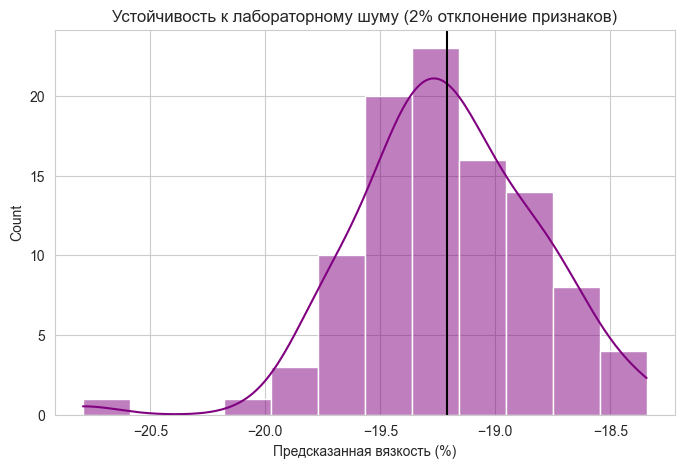

In [19]:
noise_level = 0.02 # 2% шума
n_trials = 100
noisy_preds = []

with torch.no_grad():
    for _ in range(n_trials):
        # Добавляем шум к масштабированным компонентам
        noise = np.random.normal(0, noise_level, comps_scaled.shape).astype(np.float32)
        comps_noisy = torch.tensor(comps_scaled + noise).unsqueeze(0).to(DEVICE)
        
        gf_t = torch.tensor(g_sc.transform(base_scenario['global_feats'].reshape(1, -1))).float().to(DEVICE)
        ids_t = torch.tensor(base_scenario['comp_ids']).unsqueeze(0).to(DEVICE)
        mask_t = torch.ones((1, ids_t.shape[1]), dtype=torch.bool).to(DEVICE)
        
        out, _ = model(comps_noisy, ids_t, gf_t, mask_t)
        noisy_preds.append(t_sc.inverse_transform(out.cpu().numpy())[0, 0])

plt.figure(figsize=(8, 5))
sns.histplot(noisy_preds, kde=True, color='purple')
plt.axvline(np.mean(noisy_preds), color='black', label='Среднее')
plt.title('Устойчивость к лабораторному шуму (2% отклонение признаков)')
plt.xlabel('Предсказанная вязкость (%)')
plt.show()

In [ ]:
ф